# MWE: synthetic truth scenes

Image reconstructions can only be trusted after they have recovered known images from data with realistic coverage and noise. `virgil.scenes` provides simple truths for that: an inclined Gaussian ring with a one-sided brightness asymmetry, an Archimedean "pinwheel" spiral like the dust plumes of WR 104 and WR 137, and Gaussian blobs for clumps or companions. The shapes follow those in Jonah Goldfine's frito, re-implemented in virgil conventions. Every scene is a unit-sum array, East left and North up, with position angles measured from North towards East.

This notebook shows the scenes, what their parameters do, and how a composite truth looks in the uv plane. You should come away able to build a truth image for a simulation in a line or two.

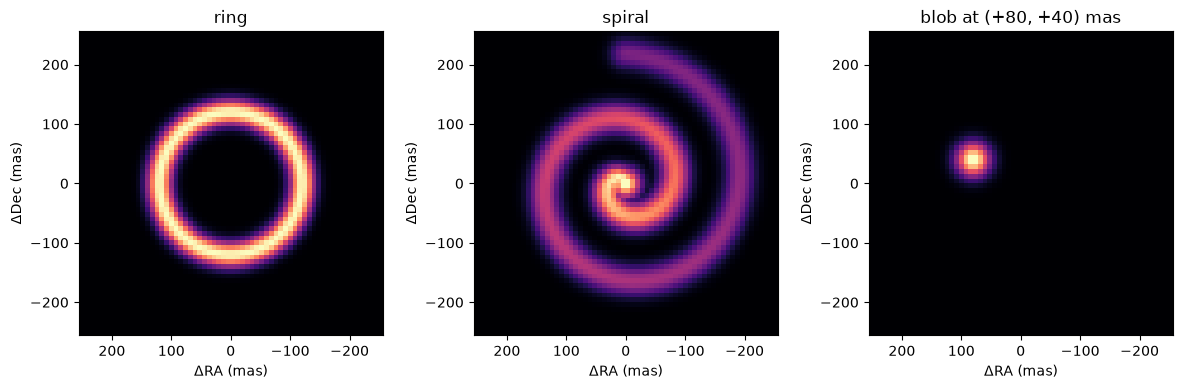

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp

from virgil._geometry import grid_visibilities
from virgil.plotting import _enforce_sky_orientation
from virgil.scenes import gaussian_blob, ring, spiral

npix, scale = 64, 8.0  # 512 mas field
extent = npix * scale / 2 * onp.array([1, -1, -1, 1])  # East left


def show(ax, image, title):
    ax.imshow(image, extent=extent, cmap="magma", origin="upper")
    _enforce_sky_orientation(ax)
    ax.set(title=title, xlabel="ΔRA (mas)", ylabel="ΔDec (mas)")


fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
show(axes[0], ring(npix, scale, 120.0, 15.0), "ring")
show(
    axes[1],
    spiral(
        npix, scale, step_mas=110.0, width_mas=18.0, turns=2.0, fade_mas=200.0
    ),
    "spiral",
)
show(
    axes[2],
    gaussian_blob(npix, scale, 20.0, dra=80.0, ddec=40.0),
    "blob at (+80, +40) mas",
)
plt.tight_layout()
plt.show()

## Ring parameters

An inclined ring is squashed along its minor axis by cos(inclination), with its major axis at `pa_deg`. The asymmetry multiplies the brightness by 1 + a cos(θ − θ₀) around the ring, where θ is each pixel's on-sky position angle, so `asymmetry_pa_deg=90` makes the East side, on the left, brightest.

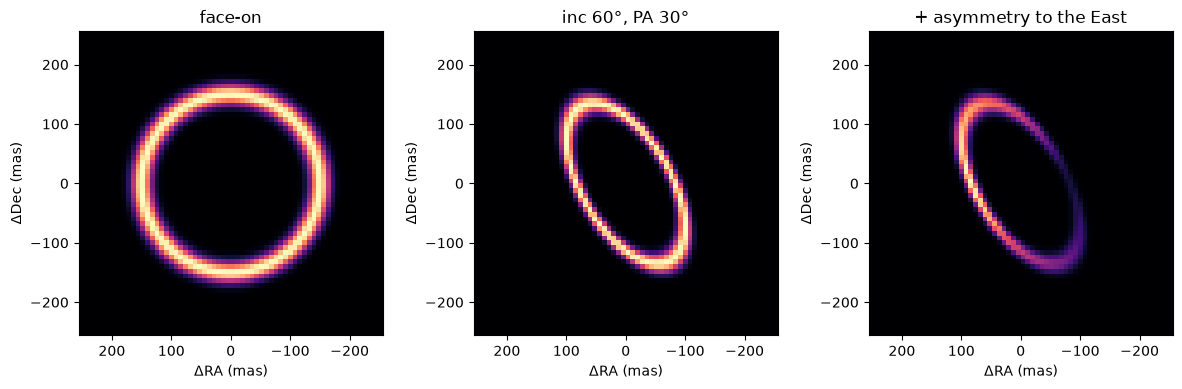

In [2]:
settings = [
    dict(inc_deg=0.0, title="face-on"),
    dict(inc_deg=60.0, pa_deg=30.0, title="inc 60°, PA 30°"),
    dict(
        inc_deg=60.0,
        pa_deg=30.0,
        asymmetry=0.8,
        asymmetry_pa_deg=90.0,
        title="+ asymmetry to the East",
    ),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, kwargs in zip(axes, settings):
    title = kwargs.pop("title")
    show(ax, ring(npix, scale, 150.0, 12.0, **kwargs), title)
plt.tight_layout()
plt.show()

## Spiral parameters

The spiral arm is r = step × θ/2π, starting at the centre at position angle `pa_deg` and winding towards increasing position angle. `turns` sets how far it goes, and `fade_mas` dims it exponentially with radius, as the dust of a colliding-wind binary cools and thins as it flows out.

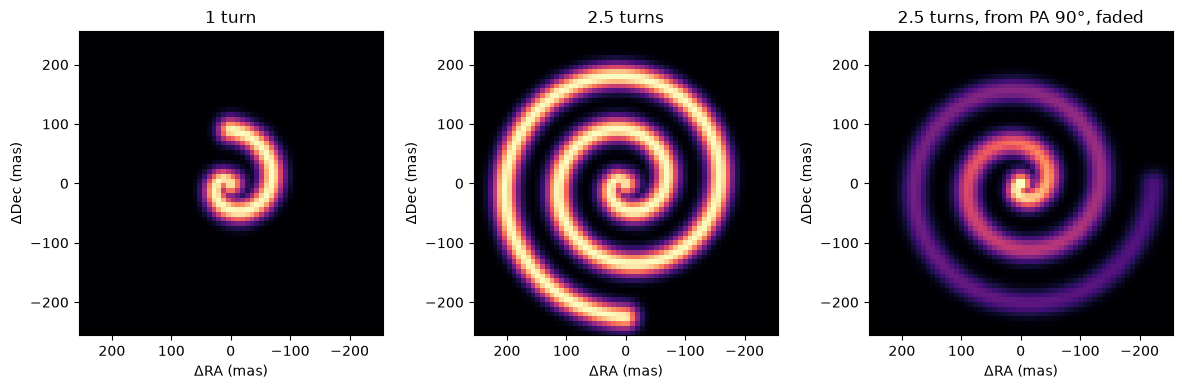

In [3]:
settings = [
    dict(turns=1.0, title="1 turn"),
    dict(turns=2.5, title="2.5 turns"),
    dict(
        turns=2.5,
        pa_deg=90.0,
        fade_mas=150.0,
        title="2.5 turns, from PA 90°, faded",
    ),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, kwargs in zip(axes, settings):
    title = kwargs.pop("title")
    show(
        ax, spiral(npix, scale, step_mas=90.0, width_mas=15.0, **kwargs), title
    )
plt.tight_layout()
plt.show()

## A composite truth in the uv plane

Scenes add like images, so a composite truth is a weighted sum renormalised to one: here a lopsided ring with a faint clump inside it. Interferometers measure the Fourier transform of this image, so the most useful view for planning a simulation is its visibility amplitude over the uv plane, computed exactly with `grid_visibilities`, the matrix Fourier transform used for AMI data. The circle marks the 6.5 m longest baseline of the JWST aperture mask at 4.3 µm.

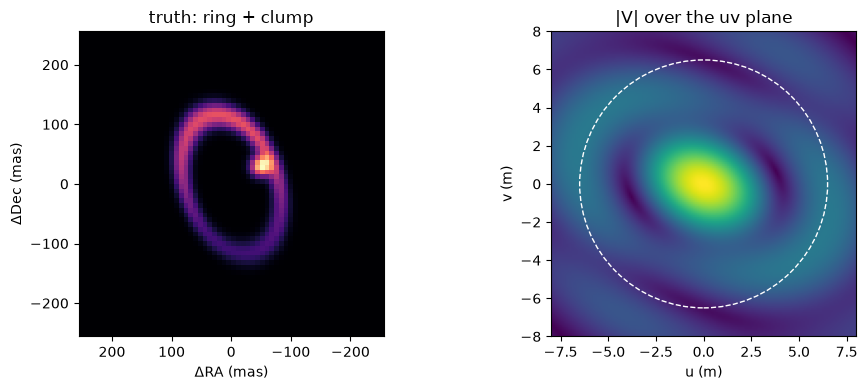

In [4]:
truth = 0.9 * ring(
    npix, scale, 120.0, 15.0, inc_deg=50.0, pa_deg=20.0, asymmetry=0.5
) + 0.1 * gaussian_blob(npix, scale, 12.0, dra=-50.0, ddec=30.0)
truth = truth / truth.sum()
wavelength = 4.3e-6
baselines = jnp.linspace(-8.0, 8.0, 161)
vis = grid_visibilities(
    truth, baselines / wavelength, baselines / wavelength, scale
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
show(axes[0], truth, "truth: ring + clump")
axes[1].imshow(
    jnp.abs(vis), extent=[-8, 8, -8, 8], origin="lower", cmap="viridis"
)
axes[1].add_patch(plt.Circle((0, 0), 6.5, fill=False, color="w", ls="--"))
axes[1].set(title="|V| over the uv plane", xlabel="u (m)", ylabel="v (m)")
plt.tight_layout()
plt.show()

## Summary

`virgil.scenes` gives unit-sum truth images (rings, spirals and blobs) in the virgil orientation, with position angles measured from North towards East. They combine by weighted sums, go straight into `Image.from_brightness`, and their transforms show which structure a given uv coverage can constrain. Stage 3 will use them as truths for recovery tests.